<a href="https://colab.research.google.com/github/max-power-126/lab1_FFNN/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from csv import reader
import time
from torch.utils.data import TensorDataset, DataLoader

In [89]:

# D= length avg 3,E=max length 4,F=bytes 5,J=inter arrival time 9,K=packet length 10


data = pd.read_csv("dataset_lab_1.csv",encoding="utf-8")
# Modo corretto ed efficiente in pandas per filtrare i valori uguali a 0 nelle colonne desiderate
rawdata_size= data.shape
######################################## Missing and Duplicate #############################

print(f"dati iniziali",data.shape)
#drop NaN

data.dropna(inplace=True)

print(f"dati No NaN",data.shape)

# Definiamo le colonne che non devono contenere zeri
columns_to_filter = [
    'Bwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Flow Bytes/s',
    'Flow IAT Mean',
    'Packet Length Mean'
]

# Creiamo una maschera booleana: per ogni riga, tutte le colonne specificate devono essere diverse da 0
# (data[col] != 0).all(axis=1) verifica che la condizione sia True per TUTTE le colonne selezionate


mask = (data[columns_to_filter] != 0.0).all(axis=1)


# Applichiamo la maschera per ottenere il dataset pulito
data_cleaned = data[mask].copy()

modified_size=data_cleaned.shape

print(f"data filtered= {modified_size}")

data_cleaned.drop_duplicates(inplace=True,keep="first")

print(f"data no duplicate= {data_cleaned.shape}")

# Mostriamo la differenza di righe prima e dopo la pulizia

# 1. Rimuoviamo i valori NaN dal dataset finale


# 2. Rimuoviamo i valori infiniti (inf e -inf)
# Selezioniamo solo le colonne numeriche per verificare la presenza di infiniti
numeric_cols = data_cleaned.select_dtypes(include=[np.number]).columns
is_infinite = np.isinf(data_cleaned[numeric_cols]).any(axis=1)

# Teniamo solo le righe che NON contengono infiniti
data_cleaned_final = data_cleaned[~is_infinite]

print(f"data no inf= {data_cleaned_final.shape}")


#############################Encoded######################################

label_encoder = LabelEncoder()
data_cleaned_final['Label'] = label_encoder.fit_transform(data_cleaned_final['Label'])

data_choosed=data_cleaned_final.copy()

########################################### Split #############################

## train = 60 %, validation = 20 % , test=20%

# Split the dataset
X = data_choosed[['Flow Duration', 'Flow IAT Mean', 'Fwd PSH Flags',
       'Bwd Packet Length Mean', 'Bwd Packet Length Max', 'Flow Bytes/s',
       'Down/Up Ratio', 'SYN Flag Count', 'Fwd Packet Length Mean',
       'Fwd IAT Std', 'Packet Length Mean', 'Fwd Packet Length Max',
       'Subflow Fwd Packets', 'Flow Packets/s', 'Total Fwd Packets',
       'Destination Port']].values
y = data_choosed['Label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)



#################### Scaling ################################################
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(y_train)
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

########################################################################


dati iniziali (31507, 17)
dati No NaN (31487, 17)
data filtered= (23773, 17)
data no duplicate= (23280, 17)
data no inf= (23280, 17)
[2 3 0 ... 0 0 2]


In [90]:
# @title
# fig, ax = plt.subplots(figsize=(10,5))
# plt.scatter(x=data["Feature_1"].values,
#             y=data["Feature_2"].values,
#             c=data["Label"].values,
#             cmap=plt.cm.RdYlBu)
# plt.show()
# plt.close()

# fig, ax = plt.subplots(figsize=(10,5))
# plt.scatter(x=data["Feature_1"].values,
#             y=data["Feature_2"].values,
#             c=data["Label"].values,
#             cmap=plt.cm.RdYlBu)
# plt.xlim(-2,2)
# plt.ylim(-2,2)
# plt.show()
# plt.close()

Task 2

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"The device is set to: {device}")

The device is set to: cuda


In [92]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-4
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [93]:
# Define the neural network
class ffnn(nn.Module):
    def __init__(self, input_size, output_size):
        super(ffnn, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_width)
        self.fc2 = nn.Linear(hidden_width, output_size)
        self.relu = activation_function()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [94]:
def training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, num_epochs, min_delta = None, patience = None):
  start_time = time.time()

  train_losses = []
  val_losses = []

  best_val_loss = float('inf')
  trigger_times = 0
  best_model_state = None
  for epoch in range(num_epochs):
    train_loss = 0
    val_loss = 0
    model.train()
    for batch_X, batch_y in train_loader:
      batch_X, batch_y = batch_X.to(device), batch_y.to(device)
      optimizer.zero_grad()
      outputs = model(batch_X)
      loss = criterion(outputs, batch_y)
      loss.backward()
      optimizer.step()
      train_loss += loss.item() * batch_X.size(0)
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
      for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        val_outputs = model(batch_X)
        loss = criterion(val_outputs, batch_y)
        val_loss += loss.item() * batch_X.size(0)
      val_loss /= len(val_dataset)
      val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
      print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

    if min_delta is not None:
      if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        trigger_times = 0
      else:
        trigger_times += 1
        if trigger_times >= patience:
          print(f"Early stopping at epoch {epoch+1} (best val loss: {best_val_loss:.6f})")
          break
    if best_model_state is not None:
      model.load_state_dict(best_model_state)

  end_time = time.time()
  elapsed_time = end_time - start_time
  print(f'The function took {elapsed_time:.4f} seconds to execute.')

  plt.figure(figsize=(10, 5))
  plt.plot(train_losses, label='Train Loss')
  plt.plot(val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.legend()
  plt.show()

  return

In [95]:
def testing_model(model, dataloader, device):
  start_time = time.time()

  model.eval()
  all_labels = []
  all_predictions = []

  with torch.no_grad():
    for inputs, labels in dataloader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      _, predicted = torch.max(outputs, 1)
      all_labels.extend(labels.cpu().numpy())
      all_predictions.extend(predicted.cpu().numpy())
  accuracy = accuracy_score(all_labels, all_predictions) * 100

  end_time = time.time()
  elapsed_time = end_time - start_time
  print(f'The function took {elapsed_time:.4f} seconds to execute.')

  return accuracy


In [96]:
# Convert data to PyTorch tensors and send to CUDA
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

In [97]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [98]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 0.0589, Val Loss: 0.0612
Epoch 40/100, Train Loss: 0.0404, Val Loss: 0.0438
Epoch 60/100, Train Loss: 0.0303, Val Loss: 0.0319
Epoch 80/100, Train Loss: 0.0258, Val Loss: 0.0274
Epoch 100/100, Train Loss: 0.0225, Val Loss: 0.0239
The function took 46.1867 seconds to execute.


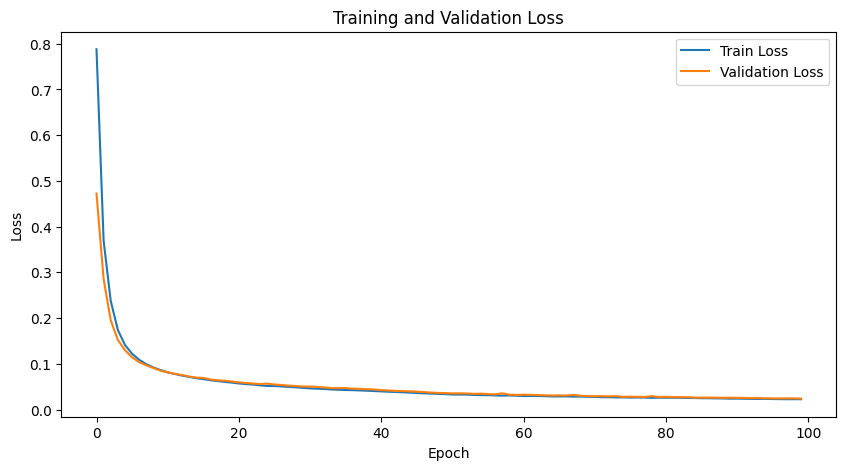

In [99]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [100]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[ 0.0667, -0.3292,  0.1786,  ...,  0.2268, -0.0631,  0.3909],
        [-0.1929, -0.4346,  0.2283,  ..., -0.1800,  0.0659,  0.1723],
        [-0.4500, -0.1638, -0.2439,  ..., -0.2832,  0.3071, -0.1567],
        ...,
        [-0.0686, -0.2856, -0.1031,  ...,  0.4153, -0.3202,  0.0920],
        [-0.0082, -0.2951, -0.3361,  ...,  0.4140,  0.2521,  0.0454],
        [-0.0631,  0.0619, -0.1134,  ...,  0.2074, -1.5864, -0.2512]],
       device='cuda:0')
Learned biases: tensor([ 0.3253,  0.1449,  0.0303,  0.1020, -0.2702,  0.0442,  0.4124,  0.6664,
        -0.0601, -0.1951,  0.4078,  0.0593,  0.3636,  0.0733,  0.3018, -0.3778,
         0.5069,  0.2508,  0.3832, -0.0208,  0.2248, -0.3097,  0.3963,  0.0633,
         0.2793, -0.1056, -0.2153, -0.2704,  0.3763,  0.3655,  0.2722,  0.2016,
         0.2895, -0.2159, -0.0493,  0.2516,  0.0859,  0.2558, -0.0532,  0.0461,
         0.5442,  0.1695, -0.1804,  0.0525,  0.4820,  0.4534,  0.2407, -0.0204,
        -0.1009,  0.2760, -0.

In [101]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.1834 seconds to execute.
The function took 0.0643 seconds to execute.
The function took 0.0614 seconds to execute.
Train Accuracy: 99.4774
Validation Accuracy: 99.3986
Test Accuracy: 99.3342
